In [2]:
#IMPLEMENTASI LOGISTIC REGRESSION (LASSO) - KASUS STUNTING

# 1. Mengimpor Pustaka Utama
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_curve, roc_auc_score)

try:
    # 2. Memuat Dataset ke dalam Sistem
    df = pd.read_excel('Preprocessed Data.xlsx')
    print("Dataset berhasil dimuat!")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat dataset: {e}")

Dataset berhasil dimuat!


In [6]:
import datetime

# Fungsi untuk menyelamatkan data berat badan yang diubah Excel menjadi tanggal
def selamatkan_berat_badan(val):
    if isinstance(val, datetime.datetime):
        # Mengubah format tanggal kembali menjadi desimal (Contoh: 8 Feb -> 8.2)
        return val.day + (val.month / 10)
    return val

# Terapkan fungsi penyelamat khusus ke kolom Weight sebelum dipaksa jadi numerik
df['Weight'] = df['Weight'].apply(selamatkan_berat_badan)

# Memaksa tipe data menjadi numerik dan menghapus baris yang benar-benar kosong/rusak
kolom_kunci = ['Gender', 'Age (Month)', 'Weight', 'Height', 'Height for Age']
for col in kolom_kunci:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=kolom_kunci).copy()
print(f"Total data bersih siap dilatih: {len(df)} baris\n")

Total data bersih siap dilatih: 40069 baris



In [8]:
# 4. Binarisasi Target (0 = Normal, 1 = Stunting)
df['Target_Stunting'] = df['Height for Age'].apply(lambda x: 0 if x == 0 else 1)

# Menampilkan Bukti Binarisasi ke Terminal
print("--- Bukti Hasil Binarisasi ---")
print(df[['Height for Age', 'Target_Stunting']].head())
print("-" * 30)

--- Bukti Hasil Binarisasi ---
   Height for Age  Target_Stunting
0               1                1
1               1                1
2               1                1
3               1                1
4               1                1
------------------------------


In [10]:
# 5. Memilih Fitur Utama (X) dan Target Biner (y)
X = df[['Gender', 'Age (Month)', 'Weight', 'Height']] 
y = df['Target_Stunting']


--- Distribusi Kelas Target ---
Target_Stunting
0    23865
1    16204
Name: count, dtype: int64
------------------------------


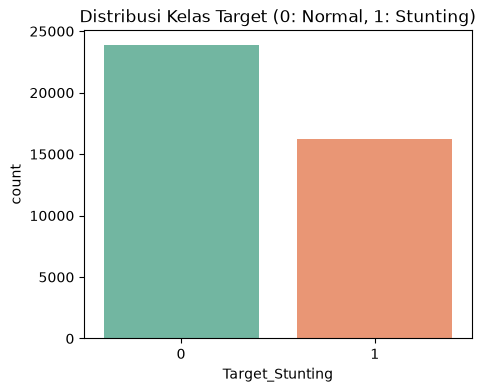

In [11]:
# 6. Menampilkan Distribusi Kelas Target (Teks & Visual)
print("\n--- Distribusi Kelas Target ---")
print(y.value_counts())
print("-" * 30)

# Menampilkan grafik hitungan kelas
plt.figure(figsize=(5,4))
sns.countplot(
  x='Target_Stunting',
  data=df,
  hue='Target_Stunting',
  palette='Set2',
  legend=False
)
plt.title('Distribusi Kelas Target (0: Normal, 1: Stunting)')
plt.show()


In [13]:
#7. Memisahkan Data Latih & Uji (Stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:
#8. Standardisasi Skala Data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
import warnings
warnings.filterwarnings('ignore') # Baris ini akan menyembunyikan semua warning

# #9. Membangun dan Melatih Model dengan Regularisasi L1
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-

In [18]:
#10. Menampilkan Koefisien Model 
coef_df = pd.DataFrame({
    'Fitur': X.columns, 
    'Koefisien': model.coef_[0]
})
print("\n--- Koefisien Model (Bobot Fitur) ---")
print(coef_df)
print("-" * 30)



--- Koefisien Model (Bobot Fitur) ---
         Fitur  Koefisien
0       Gender   0.410095
1  Age (Month)   6.565007
2       Weight  -5.503337
3       Height  -6.892416
------------------------------


In [21]:
#11. Prediksi Kelas dan Probabilitas
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Contoh Probabilitas Prediksi ---")
print(f"{'Data ke-':<10} | {'Probabilitas Stunting'}")
print("-" * 35)
for i in range(5):
    print(f"{i+1:<10} | {y_pred_proba[i]*100:.2f}%")



--- Contoh Probabilitas Prediksi ---
Data ke-   | Probabilitas Stunting
-----------------------------------
1          | 25.78%
2          | 47.95%
3          | 2.73%
4          | 66.14%
5          | 43.71%


In [22]:
#12. Evaluasi Model (Akurasi & Classification Report)
print(f"\nAkurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4)) 



Akurasi Model: 83.73%

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8509    0.8812    0.8658      4773
           1     0.8154    0.7726    0.7934      3241

    accuracy                         0.8373      8014
   macro avg     0.8331    0.8269    0.8296      8014
weighted avg     0.8365    0.8373    0.8365      8014



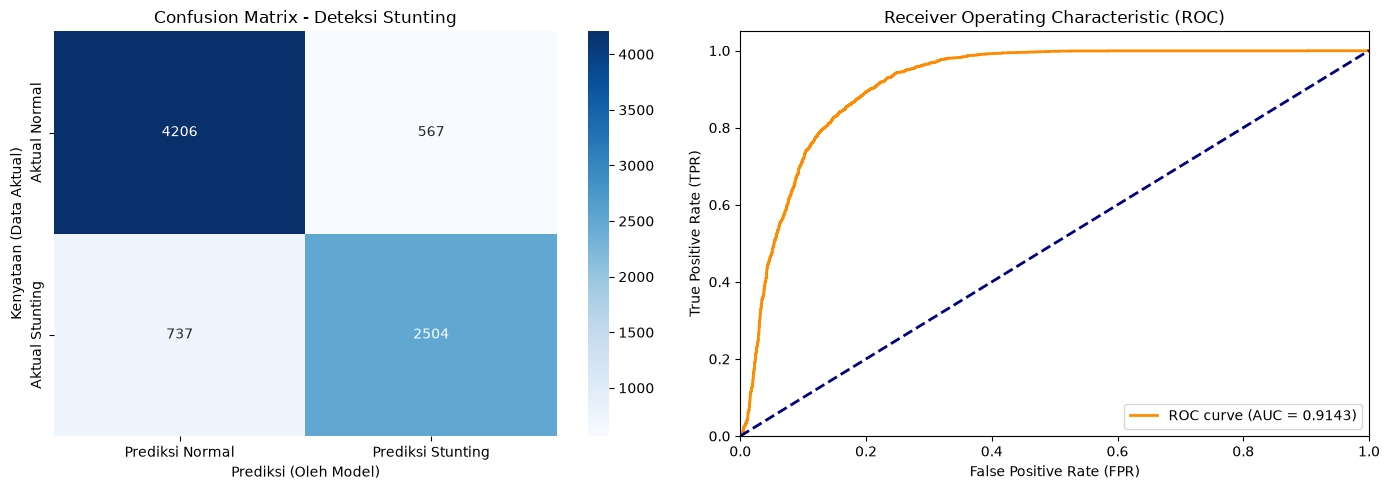

In [24]:
# 13. Visualisasi Ganda: Confusion Matrix & ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Normal', 'Prediksi Stunting'], 
            yticklabels=['Aktual Normal', 'Aktual Stunting'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Deteksi Stunting')
axes[0].set_xlabel('Prediksi (Oleh Model)')
axes[0].set_ylabel('Kenyataan (Data Aktual)')

# Plot 2: ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
